<a href="https://colab.research.google.com/github/milicak/Data_Analysis_Course/blob/main/06_Fast_Fourier_Transform_FFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [13]:
    # Time axis: 0 to 800,000 years, sampled every 1,000 years
    dt = 1000
    t = np.arange(0, 800000, dt)

    # Define the dominant orbital periods (in years)
    p_eccentricity = 100000  # Orbital shape
    p_obliquity = 41000      # Axial tilt
    p_precession = 23000     # Axial wobble

    # Create the signals (amplitudes reflect relative impact on climate)
    eccentricity_signal = 2.0 * np.sin(2 * np.pi * t / p_eccentricity)
    obliquity_signal = 1.0 * np.sin(2 * np.pi * t / p_obliquity)
    precession_signal = 0.5 * np.sin(2 * np.pi * t / p_precession)

    # Add random background noise to simulate messy real-world proxy data
    noise = np.random.normal(0, 0.8, len(t))

    # Combined temperature proxy signal
    temperature = eccentricity_signal + obliquity_signal + precession_signal + noise

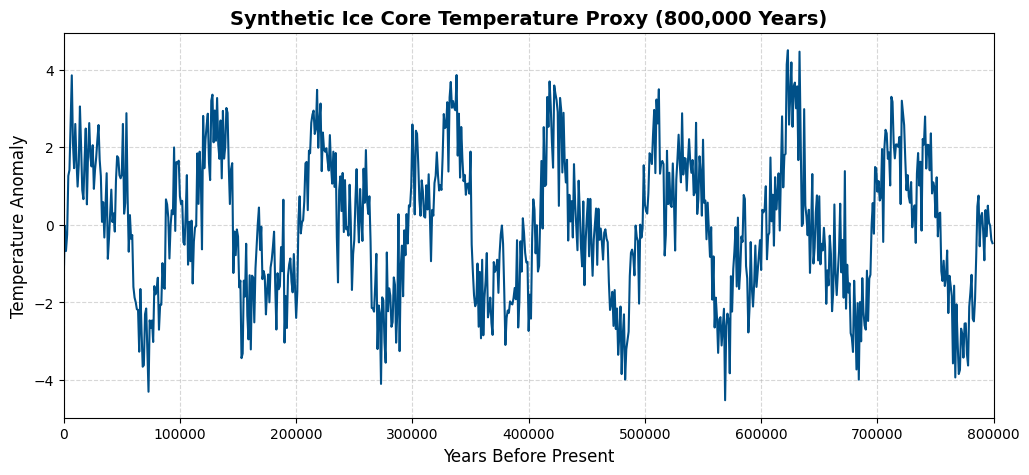

In [14]:
    fig, (ax1) = plt.subplots(1, 1, figsize=(12, 5))

    # --- Plot 1: The Time Domain (Raw Data) ---
    ax1.plot(t, temperature, color='#005088', linewidth=1.5)
    ax1.set_title('Synthetic Ice Core Temperature Proxy (800,000 Years)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Years Before Present', fontsize=12)
    ax1.set_ylabel('Temperature Anomaly', fontsize=12)
    ax1.set_xlim(0, 800000)
    ax1.grid(True, linestyle='--', alpha=0.5)


In [15]:
    from numpy import fft
    N = len(t)

    # 1. Compute the FFT
    fft_result = fft.fft(temperature)

    # 2. Calculate the Power Spectrum (magnitude squared of the FFT)
    power = np.abs(fft_result)**2

    # 3. Calculate corresponding frequencies
    frequencies = fft.fftfreq(N, dt)

    # 4. Keep only the positive half of the frequencies (FFT is symmetric)
    positive_freqs = frequencies[:N//2]
    positive_power = power[:N//2]

    # 5. Convert frequencies to Periods (Years/Cycle) for paleoclimate interpretation
    # We slice [1:] to drop the 0-frequency (DC/mean offset) to avoid dividing by zero
    periods = 1 / positive_freqs[1:]
    power_plot = positive_power[1:]

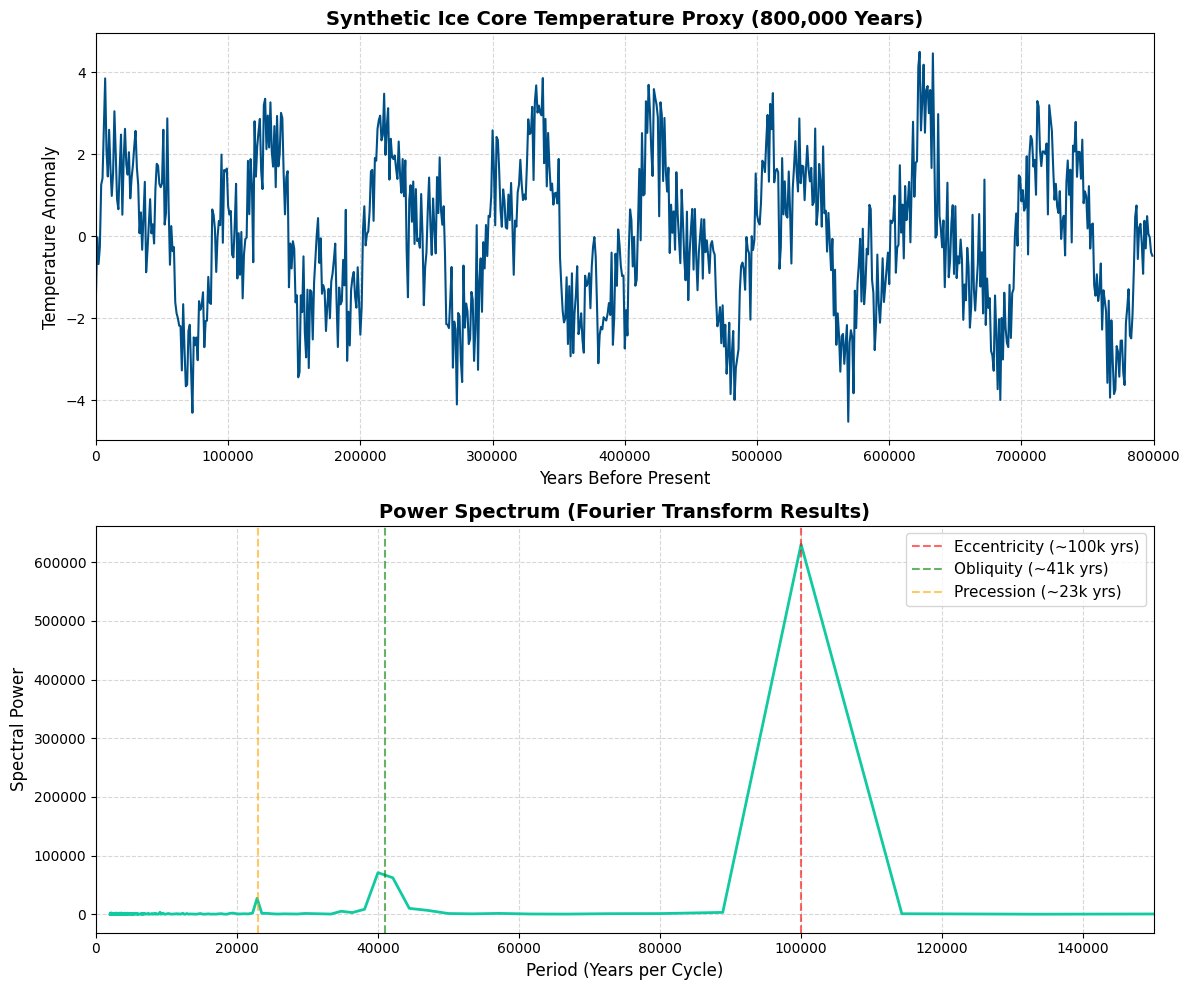

In [16]:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # --- Plot 1: The Time Domain (Raw Data) ---
    ax1.plot(t, temperature, color='#005088', linewidth=1.5)
    ax1.set_title('Synthetic Ice Core Temperature Proxy (800,000 Years)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Years Before Present', fontsize=12)
    ax1.set_ylabel('Temperature Anomaly', fontsize=12)
    ax1.set_xlim(0, 800000)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- Plot 2: The Frequency Domain (Power Spectrum) ---
    ax2.plot(periods, power_plot, color='#11caa0', linewidth=2)
    ax2.set_title('Power Spectrum (Fourier Transform Results)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Period (Years per Cycle)', fontsize=12)
    ax2.set_ylabel('Spectral Power', fontsize=12)

    # Zoom in on the relevant periods (0 to 150,000 years)
    ax2.set_xlim(0, 150000)

    # Highlight the expected Milankovitch cycles
    ax2.axvline(100000, color='red', linestyle='--', alpha=0.6, label='Eccentricity (~100k yrs)')
    ax2.axvline(41000, color='green', linestyle='--', alpha=0.6, label='Obliquity (~41k yrs)')
    ax2.axvline(23000, color='orange', linestyle='--', alpha=0.6, label='Precession (~23k yrs)')

    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define sampling interval
dt = 3600  # 1 hour in seconds

# 2. Define theoretical periods in hours
T1 = 24.0               # Diurnal cycle (24 hours)
T2 = 365.25 * 24        # Annual cycle
T3 = 5.0 * 365.25 * 24  # 5-year multi-year cycle

# 3. Create time array spanning 50 years with 1-hour steps
n_years = 50
total_seconds = n_years * 365.25 * 24 * 3600
time = np.arange(0, total_seconds, dt)

# 4. Generate synthetic temperature signal (Temp)
# Converting time (seconds) to hours for the sine function to match periods T1, T2, T3
time_hours = time / 3600.0

# Summing sine waves with a baseline of 15 degrees
Temp = (15 +
        3 * np.sin(2 * np.pi * time_hours / T1) +
        10 * np.sin(2 * np.pi * time_hours / T2) +
        2 * np.sin(2 * np.pi * time_hours / T3))

Temp = (15 -
        3 * np.cos(2 * np.pi * time_hours / T1) -
        10 * np.cos(2 * np.pi * time_hours / T2) -
        2 * np.cos(2 * np.pi * time_hours / T3))

print(f'Signal generated: {len(Temp)} hourly samples over {n_years} years.')
print(f'Variable name set to: Temp')

Signal generated: 438300 hourly samples over 50 years.
Variable name set to: Temp


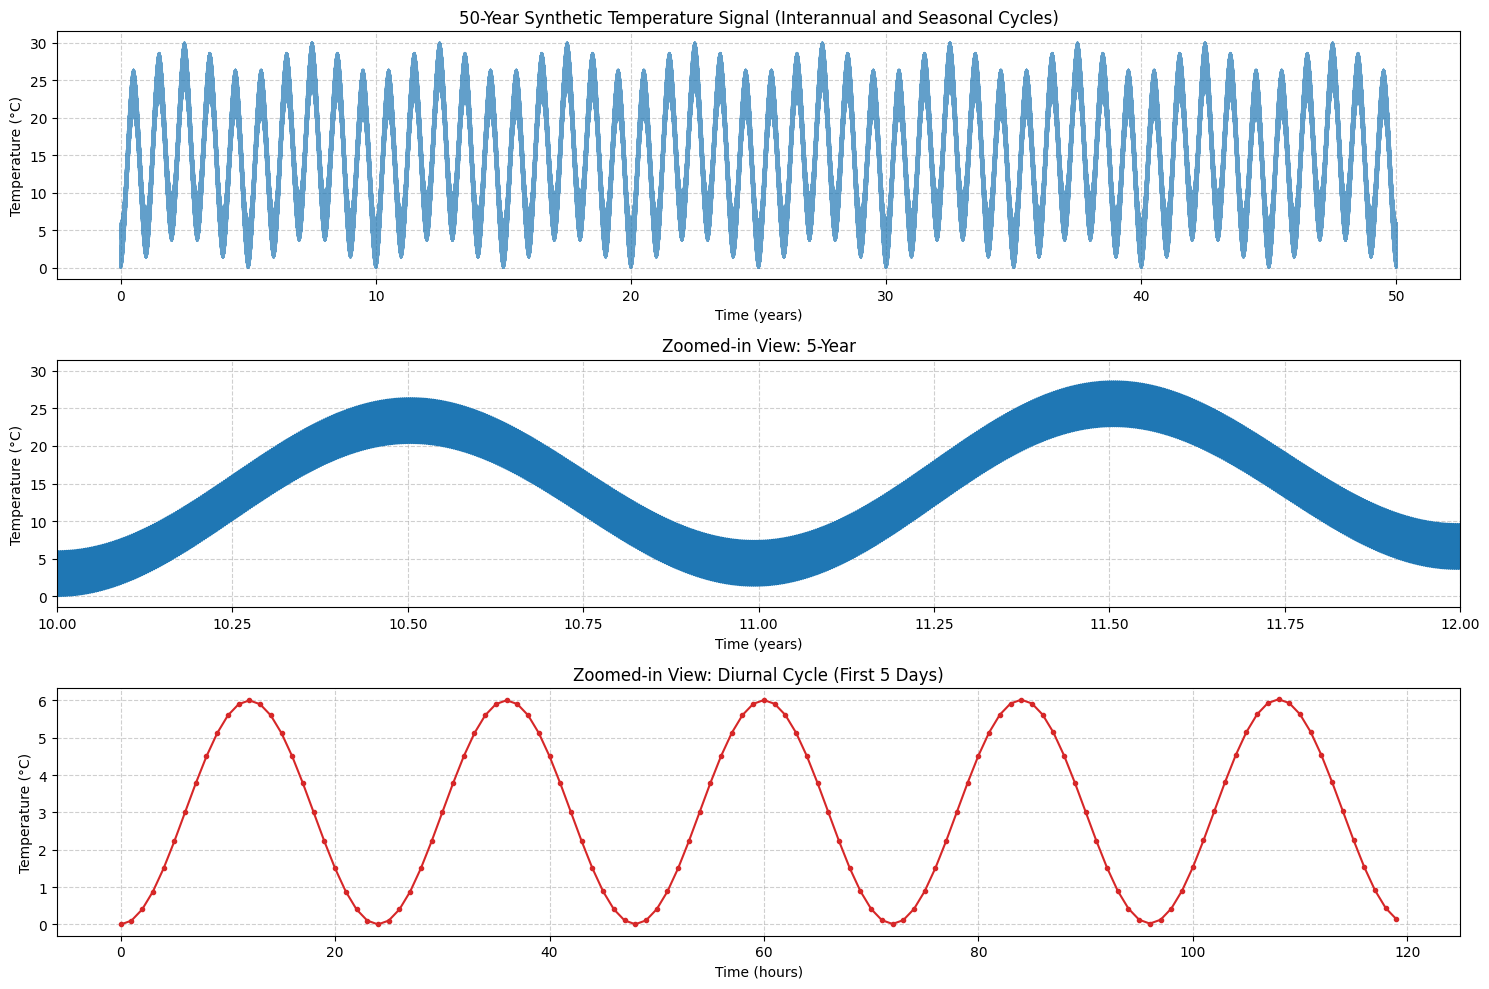

In [18]:
# Create a figure with two subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))

# 1. Full 50-year plot
time_years = time_hours / (365.25 * 24)
ax1.plot(time_years, Temp, color='tab:blue', alpha=0.7)
ax1.set_title('50-Year Synthetic Temperature Signal (Interannual and Seasonal Cycles)')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(time_years, Temp)
ax2.set_xlim(10,12)
ax2.set_title('Zoomed-in View: 5-Year')
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Temperature (°C)')
ax2.grid(True, linestyle='--', alpha=0.6)

# 3. Zoomed-in plot (First 5 days / 120 hours)
ax3.plot(time_hours[:120], Temp[:120], color='tab:red', marker='o', markersize=3)
ax3.set_title('Zoomed-in View: Diurnal Cycle (First 5 Days)')
ax3.set_xlabel('Time (hours)')
ax3.set_ylabel('Temperature (°C)')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

In [19]:
from numpy import fft

# 1. Calculate FFT
X = fft.fft(Temp)
N = len(X)

# 2. Get frequencies and magnitude
# d=1 represents 1 hour sampling spacing
frequencies = fft.fftfreq(N, d=1)
fft_magnitude = np.abs(X) / N

# 3. Handle zero-frequency to avoid divide-by-zero for periods
# We replace 0 with a very small number or handle it using np.where
with np.errstate(divide='ignore'):
    periods = np.where(frequencies != 0, 1 / frequencies, np.inf)

# 4. Create mask for positive frequencies
mask = frequencies > 0

# Store results for plotting
pos_periods = periods[mask]
pos_magnitude = fft_magnitude[mask]

print(f'FFT calculated for {N} samples.')
print(f'Detected max period in data: {np.max(pos_periods[np.isfinite(pos_periods)]):.2f} hours')
print(f'Detected min period in data: {np.min(pos_periods):.2f} hours')

FFT calculated for 438300 samples.
Detected max period in data: 438300.00 hours
Detected min period in data: 2.00 hours


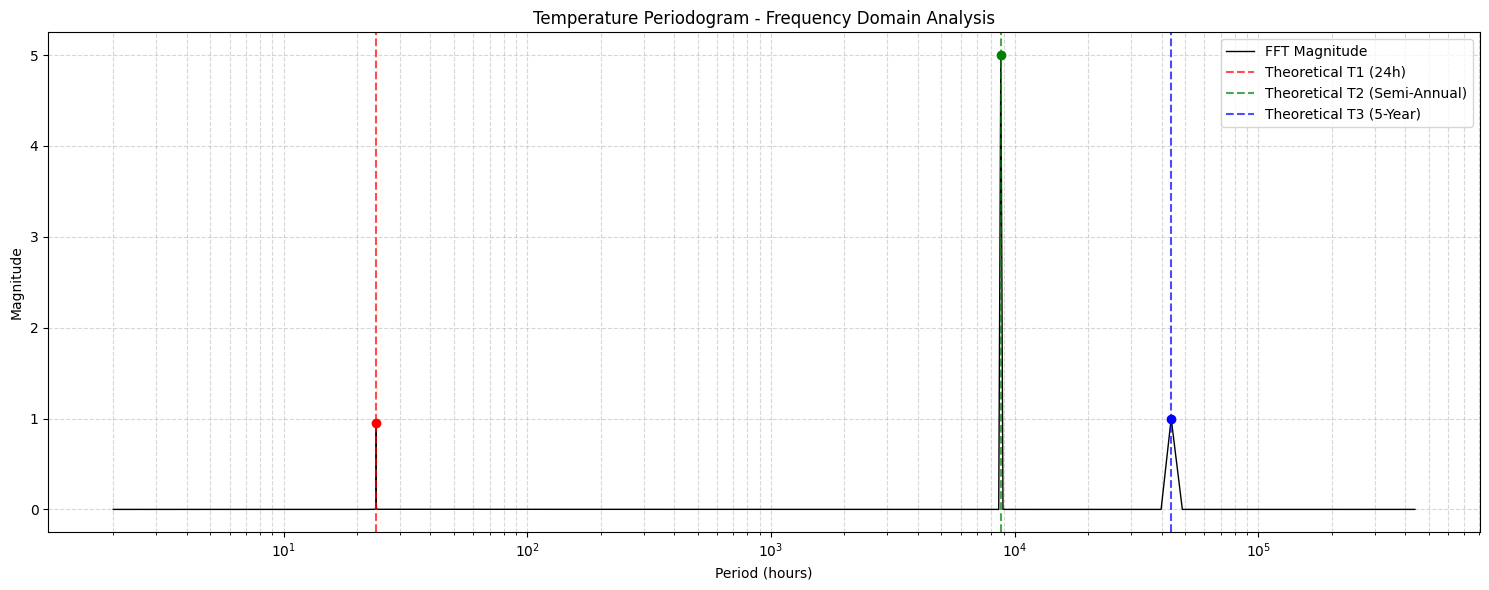

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))

# 1. Plot the magnitude against periods
ax.plot(pos_periods, pos_magnitude, color='black', linewidth=1, label='FFT Magnitude')

# 2. Set logarithmic scale for periods
ax.set_xscale('log')

# 3. Annotate theoretical periods (T1, T2, T3)
theoretical_periods = [T1, T2, T3]
labels = ['T1 (24h)', 'T2 (Semi-Annual)', 'T3 (5-Year)']
colors = ['red', 'green', 'blue']

for p, label, color in zip(theoretical_periods, labels, colors):
    ax.axvline(x=p, color=color, linestyle='--', alpha=0.7, label=f'Theoretical {label}')
    # Add a marker at the peak for better visibility
    idx = np.argmin(np.abs(pos_periods - p))
    ax.plot(pos_periods[idx], pos_magnitude[idx], 'o', color=color)

# 4. Formatting labels and title
ax.set_xlabel('Period (hours)')
ax.set_ylabel('Magnitude')
ax.set_title('Temperature Periodogram - Frequency Domain Analysis')

# 5. Legend and Grid
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
import statsmodels.tsa.api as smt
import pandas as pd
#loading Data
data = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv",index_col="Date")
data.index = pd.to_datetime(data.index)
print(data.shape)
data.head()

(3650, 1)


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


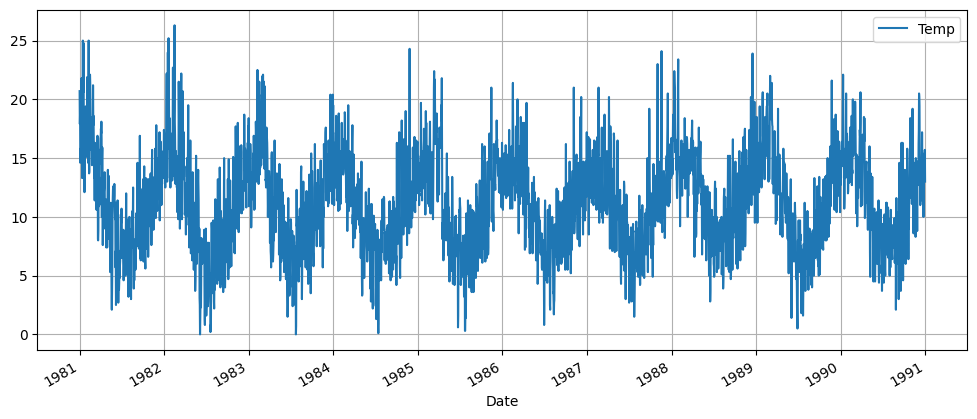

In [24]:
data.plot(figsize=(12,5));plt.grid()

In [25]:
# 2. Extract Temp and compute FFT
temp_values = data['Temp'].values
N = len(temp_values)
X = np.fft.fft(temp_values)

# 3. Calculate sample frequencies (d=1 for daily data)
frequencies = np.fft.fftfreq(N, d=1)

# 4. Compute and normalize magnitude
fft_magnitude = np.abs(X) / N

# 5. Convert frequencies to periods (days), handling zero freq
with np.errstate(divide='ignore'):
    periods = np.where(frequencies != 0, 1 / frequencies, np.inf)

# 6. Mask for positive frequencies
mask = frequencies > 0
pos_periods = periods[mask]
pos_magnitude = fft_magnitude[mask]

print(f'Data loaded: {N} rows.')
print(f'FFT calculated. Max period: {np.max(pos_periods[np.isfinite(pos_periods)]):.2f} days.')

Data loaded: 3650 rows.
FFT calculated. Max period: 3650.00 days.


In [26]:
import numpy as np

# 1. Identify the index of the maximum value in the pos_magnitude array
dominant_idx = np.argmax(pos_magnitude)
dominant_period = pos_periods[dominant_idx]
dominant_mag = pos_magnitude[dominant_idx]

# 2. Specifically check for the magnitude at the period closest to 365 days
# Find the index in pos_periods closest to 365
annual_idx = np.argmin(np.abs(pos_periods - 365.0))
annual_period_found = pos_periods[annual_idx]
annual_magnitude = pos_magnitude[annual_idx]

# 3. Print results to verify
print(f'Most dominant period: {dominant_period:.2f} days (Magnitude: {dominant_mag:.4f})')
print(f'Annual cycle (approx 365 days) found at: {annual_period_found:.2f} days (Magnitude: {annual_magnitude:.4f})')

# Variables are now stored in the kernel for visualization

Most dominant period: 365.00 days (Magnitude: 2.1060)
Annual cycle (approx 365 days) found at: 365.00 days (Magnitude: 2.1060)


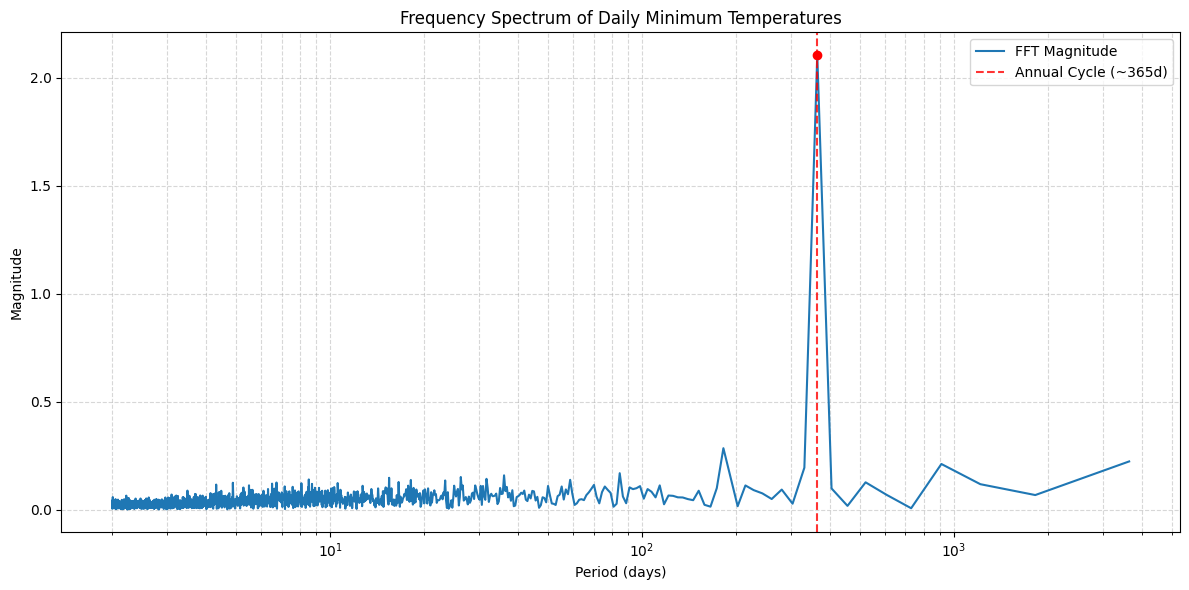

In [27]:
import matplotlib.pyplot as plt

# 1. Create a new figure
fig, ax = plt.subplots(figsize=(12, 6))

# 2. Plot magnitude against periods
ax.plot(pos_periods, pos_magnitude, color='tab:blue', label='FFT Magnitude')

# 3. Set x-axis to logarithmic scale
ax.set_xscale('log')

# 4. Highlight the 365-day annual cycle
ax.axvline(x=365.0, color='red', linestyle='--', alpha=0.8, label=f'Annual Cycle (~365d)')
ax.plot(annual_period_found, annual_magnitude, 'ro')  # Add a red dot at the peak

# 5. Label axes and title
ax.set_xlabel('Period (days)')
ax.set_ylabel('Magnitude')
ax.set_title('Frequency Spectrum of Daily Minimum Temperatures')

# 6. Add legend and grid
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# 7. Display the plot
plt.tight_layout()
plt.show()

In [28]:
# 1. Set sampling frequency (1 sample per day)
fs = 1.0

# 2. Define cutoff periods in days
period_low_pass = 90.0   # Seasonal/Long-term trends
period_high_pass = 10.0  # Synoptic weather fluctuations

# 3. Calculate cutoff frequencies (f = 1/T)
f_low = 1.0 / period_low_pass
f_high = 1.0 / period_high_pass

# 4. Calculate Nyquist frequency
nyq = 0.5 * fs

# 5. Calculate normalized cutoff frequencies (Wn)
# Wn is the frequency divided by the Nyquist frequency
wn_low = f_low / nyq
wn_high = f_high / nyq

print(f'Sampling Frequency: {fs} day^-1')
print(f'Nyquist Frequency: {nyq} day^-1')
print(f'Low-pass Cutoff (90d): f={f_low:.4f}, Wn={wn_low:.4f}')
print(f'High-pass Cutoff (10d): f={f_high:.4f}, Wn={wn_high:.4f}')

Sampling Frequency: 1.0 day^-1
Nyquist Frequency: 0.5 day^-1
Low-pass Cutoff (90d): f=0.0111, Wn=0.0222
High-pass Cutoff (10d): f=0.1000, Wn=0.2000


In [29]:
from scipy.signal import butter, filtfilt

# 1. Design and apply Low-pass filter (Seasonal Trend: periods > 90 days)
b_low, a_low = butter(4, wn_low, btype='low')
data['Seasonal_Trend'] = filtfilt(b_low, a_low, data['Temp'])

# 2. Design and apply High-pass filter (Weather Residuals: periods < 10 days)
b_high, a_high = butter(4, wn_high, btype='high')
data['Weather_Residuals'] = filtfilt(b_high, a_high, data['Temp'])

# 3. Verify results
print('Filtering complete. Added columns: Seasonal_Trend, Weather_Residuals.')
print(data[['Temp', 'Seasonal_Trend', 'Weather_Residuals']].head())

Filtering complete. Added columns: Seasonal_Trend, Weather_Residuals.
            Temp  Seasonal_Trend  Weather_Residuals
Date                                               
1981-01-01  20.7       20.273985           0.001779
1981-01-02  17.9       20.205223          -1.104069
1981-01-03  18.8       20.134551           1.212057
1981-01-04  14.6       20.062090          -2.039205
1981-01-05  15.8       19.987963          -0.415877


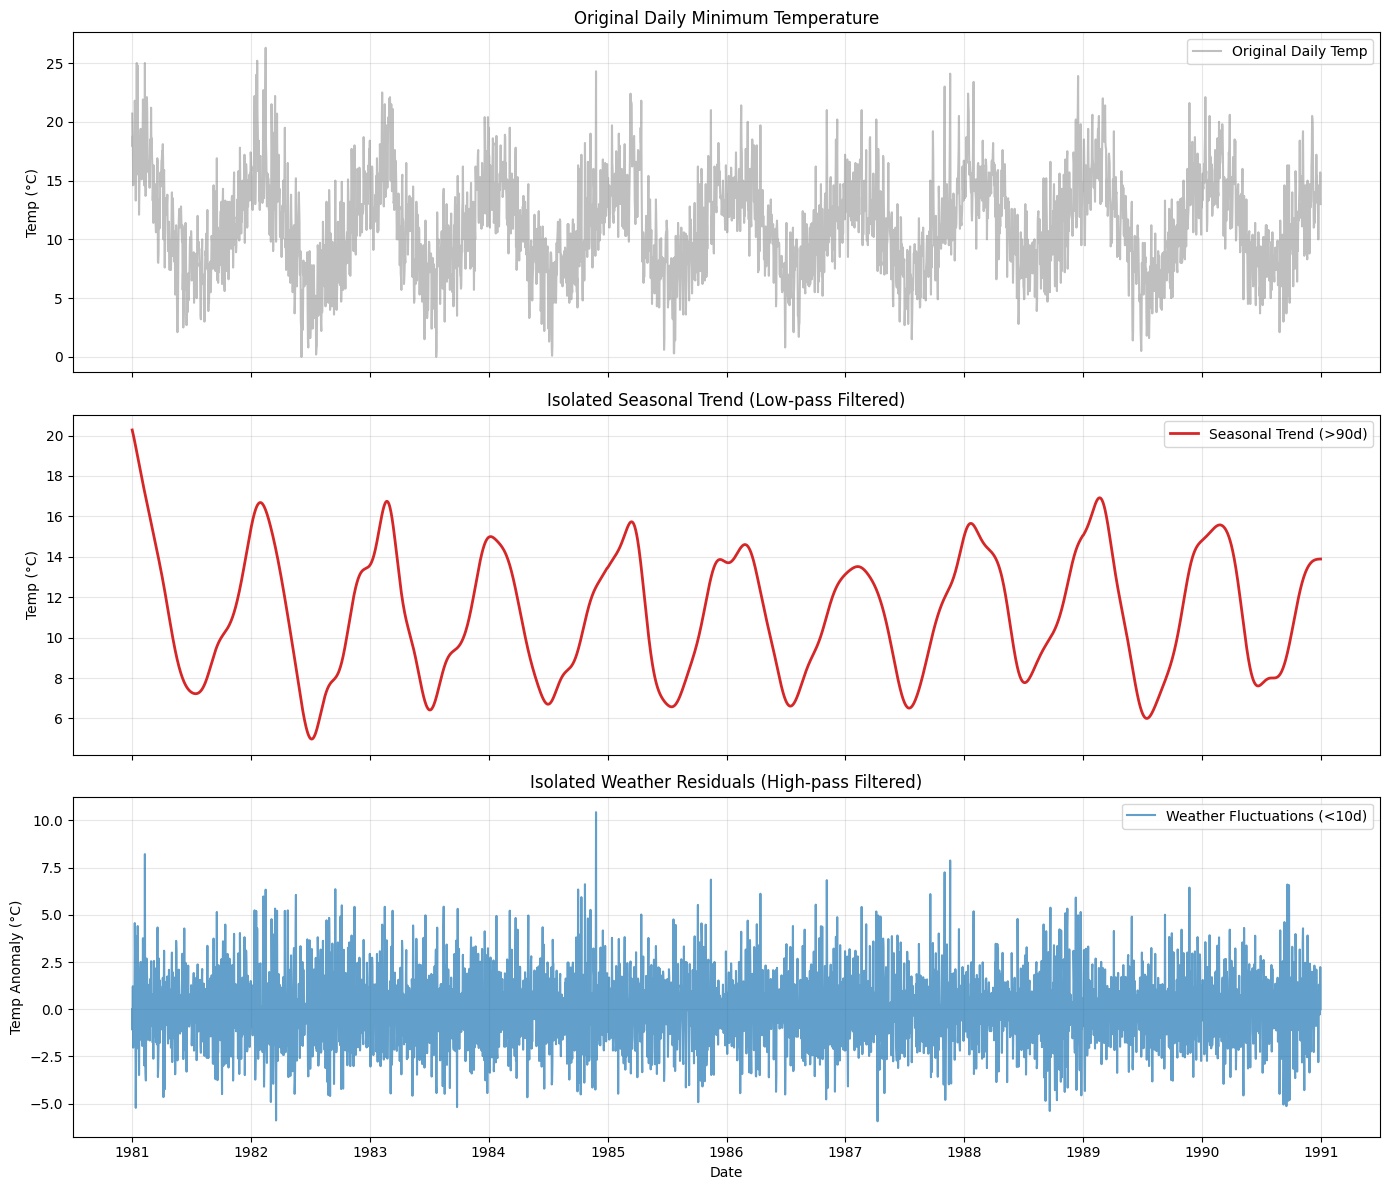

In [30]:
import matplotlib.pyplot as plt

# 1. Create a figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 2. Plot Original Signal
ax1.plot(data.index, data['Temp'], color='gray', alpha=0.5, label='Original Daily Temp')
ax1.set_title('Original Daily Minimum Temperature')
ax1.set_ylabel('Temp (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3. Plot Seasonal Trend (Low-pass filtered)
ax2.plot(data.index, data['Seasonal_Trend'], color='tab:red', linewidth=2, label='Seasonal Trend (>90d)')
ax2.set_title('Isolated Seasonal Trend (Low-pass Filtered)')
ax2.set_ylabel('Temp (°C)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 4. Plot Weather Residuals (High-pass filtered)
ax3.plot(data.index, data['Weather_Residuals'], color='tab:blue', alpha=0.7, label='Weather Fluctuations (<10d)')
ax3.set_title('Isolated Weather Residuals (High-pass Filtered)')
ax3.set_xlabel('Date')
ax3.set_ylabel('Temp Anomaly (°C)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
# Corrected URL pointing to the actual NetCDF file
# url = 'https://psl.noaa.gov/thredds/fileServer/Datasets/noaa.oisst.v2/sst.oisst.mon.mean.1982.nc'
url = 'https://psl.noaa.gov/thredds/fileServer/Datasets/noaa.oisst.v2/sst.mnmean.nc'
!wget $url

--2026-03-23 06:36:48--  https://psl.noaa.gov/thredds/fileServer/Datasets/noaa.oisst.v2/sst.mnmean.nc
Resolving psl.noaa.gov (psl.noaa.gov)... 140.172.38.12
Connecting to psl.noaa.gov (psl.noaa.gov)|140.172.38.12|:443... connected.
HTTP request sent, awaiting response... 200 
Length: 64038940 (61M) [application/x-netcdf]
Saving to: ‘sst.mnmean.nc.1’

sst.mnmean.nc.1      16%[==>                 ]  10.01M  26.6MB/s    in 0.4s    

2026-03-23 06:36:49 (26.6 MB/s) - Connection closed at byte 10497737. Retrying.

--2026-03-23 06:36:50--  (try: 2)  https://psl.noaa.gov/thredds/fileServer/Datasets/noaa.oisst.v2/sst.mnmean.nc
Connecting to psl.noaa.gov (psl.noaa.gov)|140.172.38.12|:443... connected.
HTTP request sent, awaiting response... 206 
Length: 64038940 (61M), 53541203 (51M) remaining [application/x-netcdf]
Saving to: ‘sst.mnmean.nc.1’

sst.mnmean.nc.1      34%[+++==>              ]  21.34M   571KB/s    in 15s     

2026-03-23 06:37:05 (794 KB/s) - Connection closed at byte 22380433. R

In [2]:
!pip install cartopy

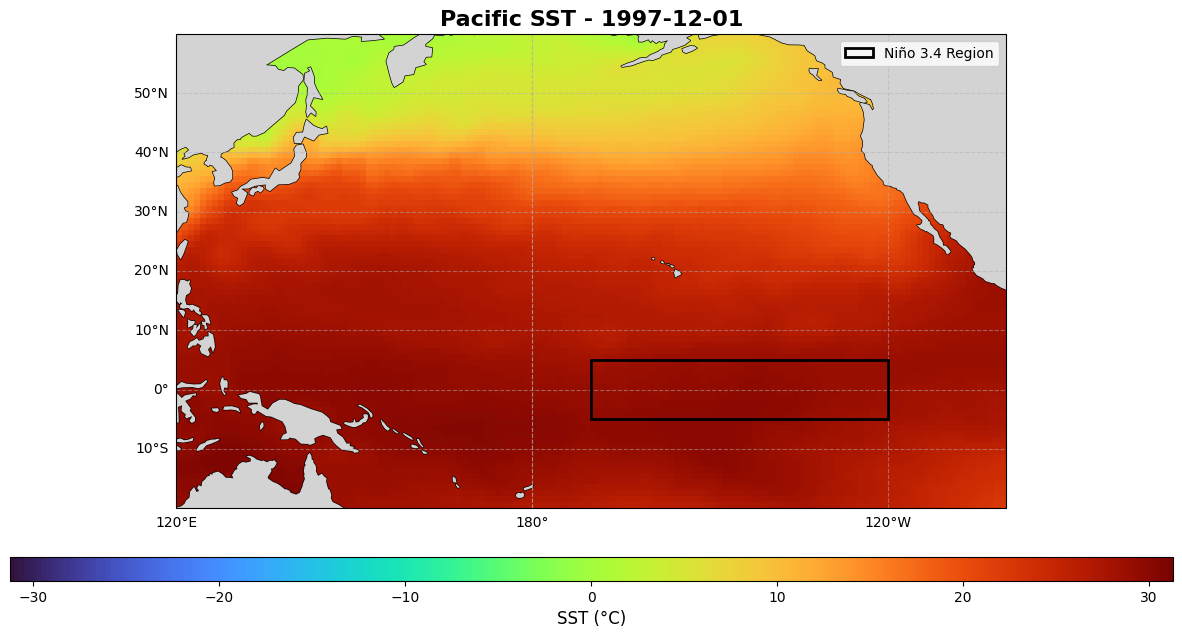

In [3]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = xr.open_dataset('sst.mnmean.nc')
df = df.sel(time=slice('1982-01-01','2022-12-31'))
df2 = df.sel(lon=slice(120,260),lat=slice(60,-20))

# 1. Select a specific time slice (Dec 1997 - a strong El Niño event)
time_slice = "1997-12-01"
sst_slice = df2.sst.sel(time=time_slice)

# 2. Initialize figure and axis with PlateCarree projection centered on the Pacific
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# 3. Plot the SST anomalies
im = sst_slice.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="turbo",
    add_colorbar=False
)

# 4. Add high-resolution geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.5)

# 5. Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 6. Draw the Niño 3.4 bounding box (5N-5S, 190E-240E)
# Rectangle(xy, width, height) where xy is bottom-left corner
nino_box = mpatches.Rectangle(
    (190, -5), 50, 10,
    linewidth=2, edgecolor="black", facecolor="none",
    transform=ccrs.PlateCarree(), zorder=10, label="Niño 3.4 Region"
)
ax.add_patch(nino_box)

# 7. Set extent to focus on the Pacific (lon 120-260, lat -20-60)
ax.set_extent([120, 260, -20, 60], crs=ccrs.PlateCarree())

# 8. Add colorbar and titles
cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.08, aspect=50)
cbar.set_label("SST (°C)", fontsize=12)

plt.title(f"Pacific SST - {time_slice}", fontsize=16, fontweight="bold")
plt.legend(loc="upper right")

In [4]:
    df = xr.open_dataset('sst.mnmean.nc')

    # 1. Slice by time (1982-2022)
    df_time = df.sel(time=slice('1982-01-01', '2022-12-31'))

    # 2. Slice by Pacific region as requested
    df_pac = df_time.sel(lon=slice(120, 260), lat=slice(60, -20))

    print("Removing seasonal cycle (calculating anomalies)...")
    # 3. Calculate monthly climatology (average Januarys, average Februarys, etc.)
    climatology = df_pac.groupby('time.month').mean('time')

    # 4. Subtract climatology from the original data to get anomalies
    anomalies = df_pac.groupby('time.month') - climatology

    print("Extracting Niño 3.4 region time series...")
    # 5. Extract the Niño 3.4 region (5N-5S, 170W-120W -> 190E-240E)
    # Note: OISST latitudes are descending, so slice(5, -5) is correct
    nino34_region = anomalies.sel(lat=slice(5, -5), lon=slice(190, 240))

Removing seasonal cycle (calculating anomalies)...
Extracting Niño 3.4 region time series...


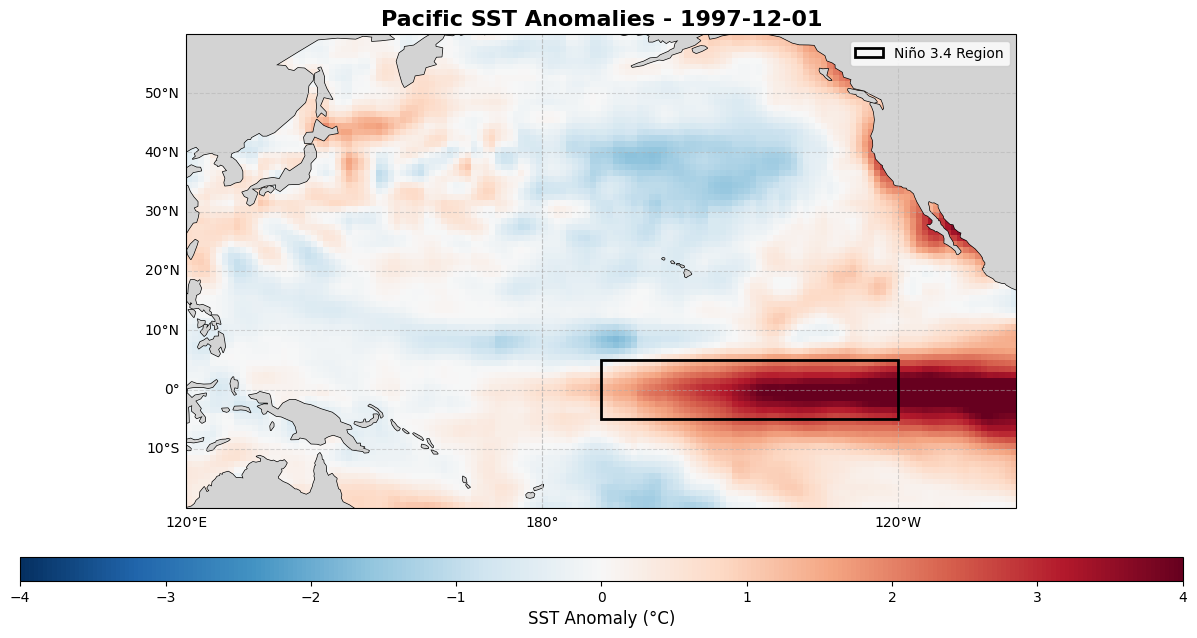

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Select a specific time slice (Dec 1997 - a strong El Niño event)
time_slice = "1997-12-01"
sst_anomaly_slice = anomalies.sst.sel(time=time_slice)

# 2. Initialize figure and axis with PlateCarree projection centered on the Pacific
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# 3. Plot the SST anomalies
im = sst_anomaly_slice.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-4, vmax=4,
    add_colorbar=False
)

# 4. Add high-resolution geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.5)

# 5. Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 6. Draw the Niño 3.4 bounding box (5N-5S, 190E-240E)
# Rectangle(xy, width, height) where xy is bottom-left corner
nino_box = mpatches.Rectangle(
    (190, -5), 50, 10,
    linewidth=2, edgecolor="black", facecolor="none",
    transform=ccrs.PlateCarree(), zorder=10, label="Niño 3.4 Region"
)
ax.add_patch(nino_box)

# 7. Set extent to focus on the Pacific (lon 120-260, lat -20-60)
ax.set_extent([120, 260, -20, 60], crs=ccrs.PlateCarree())

# 8. Add colorbar and titles
cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.08, aspect=50)
cbar.set_label("SST Anomaly (°C)", fontsize=12)

plt.title(f"Pacific SST Anomalies - {time_slice}", fontsize=16, fontweight="bold")
plt.legend(loc="upper right")

In [8]:
# 1. Access the nino34_region Dataset created previously
# (Assuming nino34_region exists in the kernel from previous cells)

# 2. Calculate the latitude weights
weights = np.cos(np.deg2rad(nino34_region.lat))

# 3 & 4. Isolate the 'sst' DataArray and apply weighted mean
# This avoids the ValueError by only targeting dimensions that exist in 'sst'
nino34_index_da = nino34_region.sst.weighted(weights).mean(dim=['lat', 'lon'])

# 5. Store the resulting time series in the requested variable name
nino34_index = nino34_index_da

# 6. Extract raw numpy arrays for FFT analysis
sst_values = nino34_index.values
time_values = nino34_index.time.values

print(f'Successfully calculated Niño 3.4 Index.')
print(f'Number of monthly samples: {len(sst_values)}')
print(f'Time range: {time_values[0]} to {time_values[-1]}')

Successfully calculated Niño 3.4 Index.
Number of monthly samples: 492
Time range: 1982-01-01T00:00:00.000000000 to 2022-12-01T00:00:00.000000000


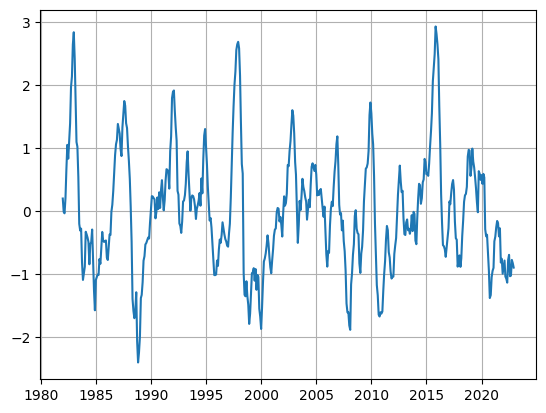

In [9]:
plt.plot(time_values,sst_values);plt.grid();

In [10]:
# 1. Compute the FFT of the monthly Niño 3.4 index
# sst_values contains the monthly anomalies calculated in the previous step
N = len(sst_values)
fft_result = np.fft.fft(sst_values)

# 2. Calculate the Power Spectrum (magnitude squared)
# We normalize by N to keep scales comparable
power_spectrum = (np.abs(fft_result) ** 2) / N

# 3. Generate frequencies
# d=1 because data is sampled monthly (1 month step)
frequencies = np.fft.fftfreq(N, d=1)

# 4. Filter for positive frequencies and calculate periods in years
# 12 months/year, so frequency in cycles per year is freqs * 12
mask = frequencies > 0
pos_freqs = frequencies[mask]
pos_power = power_spectrum[mask]

# Period (years) = 1 / (frequency in cycles per month * 12 months/year)
enso_periods = 1 / (pos_freqs * 12)
enso_power = pos_power

print(f'FFT calculation complete for {N} monthly samples.')
print(f'Max period detected: {np.max(enso_periods):.2f} years')
print(f'Min period detected: {np.min(enso_periods):.2f} years')
# enso_periods and enso_power are now ready for visualization

FFT calculation complete for 492 monthly samples.
Max period detected: 41.00 years
Min period detected: 0.17 years


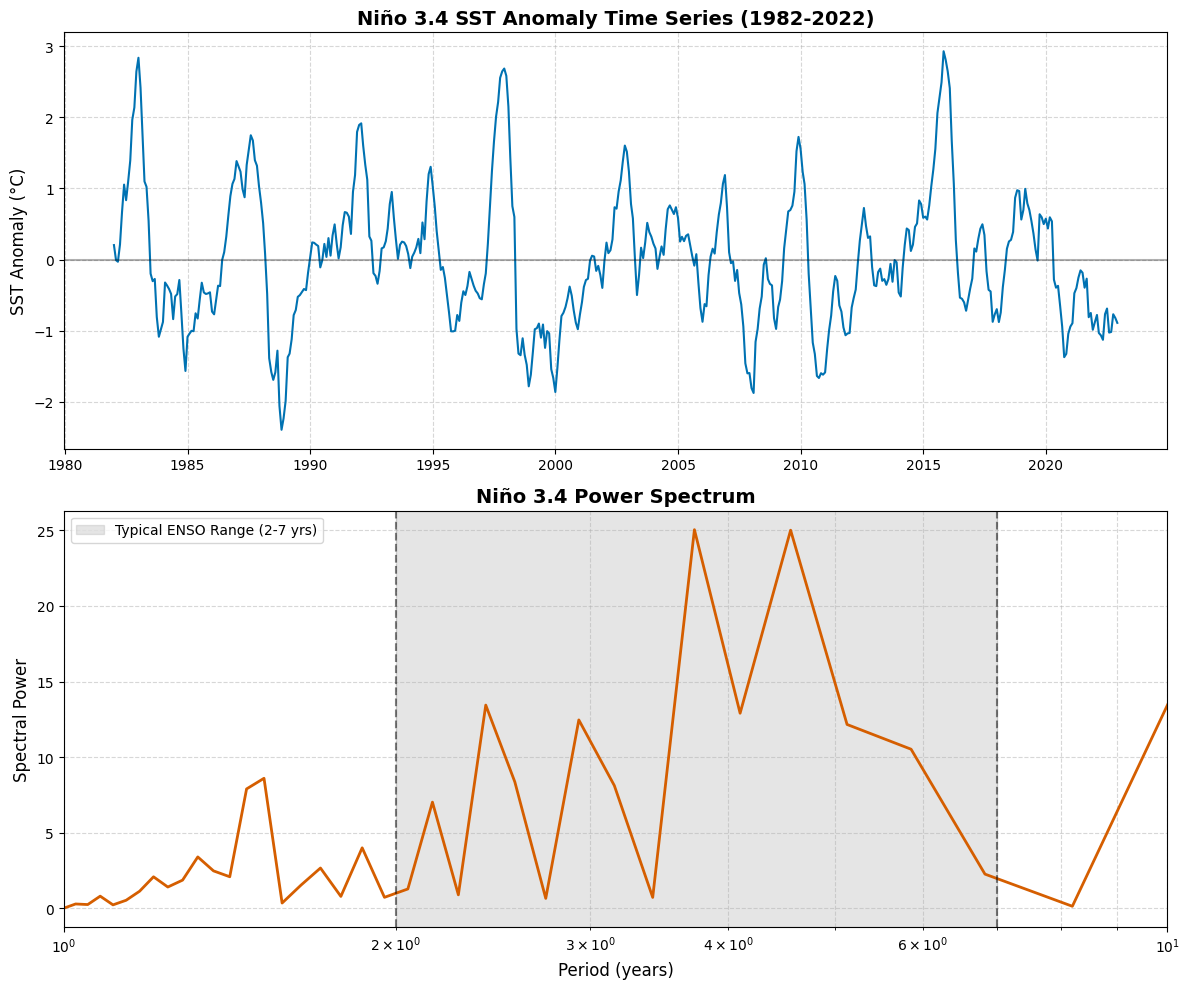

In [11]:
import matplotlib.pyplot as plt

# 1. Create a figure with two vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 2. Plot Niño 3.4 Time Series
ax1.plot(time_values, sst_values, color='#0072b2', linewidth=1.5)
ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
ax1.set_title('Niño 3.4 SST Anomaly Time Series (1982-2022)', fontsize=14, fontweight='bold')
ax1.set_ylabel('SST Anomaly (°C)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# 3. Plot Power Spectrum against periods
ax2.plot(enso_periods, enso_power, color='#d55e00', linewidth=2)

# 4. Use logarithmic scale and set limits for periods
ax2.set_xscale('log')
ax2.set_xlim(1, 10)

# 5. Highlight the typical ENSO range (2-7 years)
ax2.axvspan(2, 7, color='gray', alpha=0.2, label='Typical ENSO Range (2-7 yrs)')
ax2.axvline(2, color='black', linestyle='--', alpha=0.5)
ax2.axvline(7, color='black', linestyle='--', alpha=0.5)

# 6. Labeling and formatting for the second plot
ax2.set_title('Niño 3.4 Power Spectrum', fontsize=14, fontweight='bold')
ax2.set_xlabel('Period (years)', fontsize=12)
ax2.set_ylabel('Spectral Power', fontsize=12)
ax2.legend()
ax2.grid(True, which='both', linestyle='--', alpha=0.5)

# 7. Adjust layout and display
plt.tight_layout()
plt.show()